In [1]:
import tskit
import numpy as np

In [8]:
def get_all_sets(tree:tskit.Tree):
    sets=[]
    for i in tree.nodes():
        if tree.is_sample(i):
            pass
        else:
            sets.append(set(tree.leaves(i)))
    return sets
def branch_rf(tree1:tskit.Tree,tree2:tskit.Tree):
    #branch_rf with give a value for each branch in tree1, where the value is the maximal correlation of the samples being covered for focal branch and any branch in tree2
    sets2=get_all_sets(tree2)
    nds={}
    for nd in tree1.nodes():
        if tree1.is_root(nd):
            nds[nd] = None
            continue
        if (tree1.is_sample(nd)):
            nds[nd]=1
            continue

        s = set(tree1.leaves(nd))

        best_val = -1
        best_s2 = None

        for s2 in sets2:
            inter = len(s & s2)
            denom = max(len(s), len(s2))
            val = inter / denom if denom > 0 else 0

            if val > best_val:
                best_val = val
                best_s2 = s2
        nds[nd]=best_val
    return nds

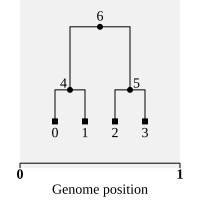

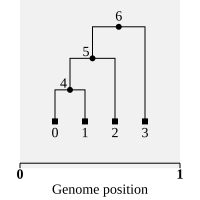

In [5]:
import tskit
import io
from IPython.display import display, SVG

nodes1 = """\
is_sample   individual   time
1           -1           0
1           -1           0
1           -1           0
1           -1           0
0           -1           1
0           -1           1
0           -1           3
"""

edges1 = """\
left   right   parent  child
0      1       4       0
0      1       4       1
0      1       5       2
0      1       5       3
0      1       6       4
0      1       6       5
"""
ts1 = tskit.load_text(
    nodes=io.StringIO(nodes1),
    edges=io.StringIO(edges1),
    strict=False
)
display(ts1.draw_svg())

import tskit
import io
from IPython.display import display, SVG

nodes2 = """\
is_sample   individual   time
1   -1   0      # 0
1   -1   0      # 1
1   -1   0      # 2
1   -1   0      # 3
0   -1   1      # 4 = coalescence of (0,2)
0   -1   2      # 5 = coalescence of (4,1)
0   -1   3      # 6 = coalescence of (5,3)
"""

edges2 = """\
left   right   parent  child
0   1   4   0
0   1   4   1

0   1   5   4
0   1   5   2

0   1   6   5
0   1   6   3
"""
ts2 = tskit.load_text(
    nodes=io.StringIO(nodes2),
    edges=io.StringIO(edges2),
    strict=False
)
display(ts2.draw_svg())

In [9]:
nds=branch_rf(ts1.at(0),ts2.at(0))

In [10]:
nds

{6: None, 4: 1.0, 0: 1, 1: 1, 5: 0.5, 2: 1, 3: 1}